In [3]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import re

import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import textgrid
from pathlib import Path

from src.stimuli import POD_dict

In [4]:
score_percentile_threshold = 90
percentile_filter_metric = "roc_auc"

tg_dir = "textgrids"

In [5]:
plot_times = np.arange(120) / 100 - 0.1

In [6]:
scores = pd.read_csv("outputs/single_electrode_decoding/scores.csv")

In [7]:
scores

,target,subject,electrode_idx,phoneme_pair,smin,smax,fold,roc_auc,f1_macro,accuracy
0,lexical_evidence,EC279,0,bm,0,10,0,0.555556,0.520625,0.520833
1,lexical_evidence,EC279,0,bm,0,10,1,0.524740,0.499783,0.500000
2,lexical_evidence,EC279,0,bm,0,10,2,0.475260,0.446415,0.447917
3,lexical_evidence,EC279,0,dn,0,10,0,0.579427,0.527094,0.531250
4,lexical_evidence,EC279,0,dn,0,10,1,0.574219,0.520833,0.520833
...,...,...,...,...,...,...,...,...,...,...
695947,mismatch_left_right,EC250,254,dn,115,120,1,0.526042,0.500000,0.500000
695948,mismatch_left_right,EC250,254,dn,115,120,2,0.565972,0.499130,0.500000
695949,mismatch_left_right,EC250,254,pb,115,120,0,0.456597,0.357143,0.375000
695950,mismatch_left_right,EC250,254,pb,115,120,1,0.513889,0.477124,0.479167


In [8]:
metric_columns = ["roc_auc", "f1_macro", "accuracy"]
scores.melt(id_vars=list(set(scores.columns) - set(metric_columns)),
            value_vars=metric_columns)

,fold,smin,electrode_idx,smax,target,phoneme_pair,subject,variable,value
0,0,0,0,10,lexical_evidence,bm,EC279,roc_auc,0.555556
1,1,0,0,10,lexical_evidence,bm,EC279,roc_auc,0.524740
2,2,0,0,10,lexical_evidence,bm,EC279,roc_auc,0.475260
3,0,0,0,10,lexical_evidence,dn,EC279,roc_auc,0.579427
4,1,0,0,10,lexical_evidence,dn,EC279,roc_auc,0.574219
...,...,...,...,...,...,...,...,...,...
2087851,1,115,254,120,mismatch_left_right,dn,EC250,accuracy,0.500000
2087852,2,115,254,120,mismatch_left_right,dn,EC250,accuracy,0.500000
2087853,0,115,254,120,mismatch_left_right,pb,EC250,accuracy,0.375000
2087854,1,115,254,120,mismatch_left_right,pb,EC250,accuracy,0.479167


In [9]:
scores_avg = scores.melt(
        id_vars=list(set(scores.columns) - set(metric_columns)),
        value_vars=metric_columns) \
    .groupby(["target", "subject", "electrode_idx", "phoneme_pair", "smin", "smax", "variable"]).value.mean().reset_index()
scores_avg["s_center"] = (scores_avg.smin + scores_avg.smax) / 2
scores_avg["t_center"] = (scores_avg.s_center - 10) / 100
scores_avg

,target,subject,electrode_idx,phoneme_pair,smin,smax,variable,value,s_center,t_center
0,lexical_evidence,EC243,54,bm,0,10,accuracy,0.541667,5.0,-0.050
1,lexical_evidence,EC243,54,bm,0,10,f1_macro,0.541335,5.0,-0.050
2,lexical_evidence,EC243,54,bm,0,10,roc_auc,0.517650,5.0,-0.050
3,lexical_evidence,EC243,54,bm,5,15,accuracy,0.548611,10.0,0.000
4,lexical_evidence,EC243,54,bm,5,15,f1_macro,0.548177,10.0,0.000
...,...,...,...,...,...,...,...,...,...,...
695947,mismatch_left_right,EC287,201,pb,110,120,f1_macro,0.497520,115.0,1.050
695948,mismatch_left_right,EC287,201,pb,110,120,roc_auc,0.458333,115.0,1.050
695949,mismatch_left_right,EC287,201,pb,115,120,accuracy,0.489583,117.5,1.075
695950,mismatch_left_right,EC287,201,pb,115,120,f1_macro,0.477921,117.5,1.075


/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/scratch/jgauthier/

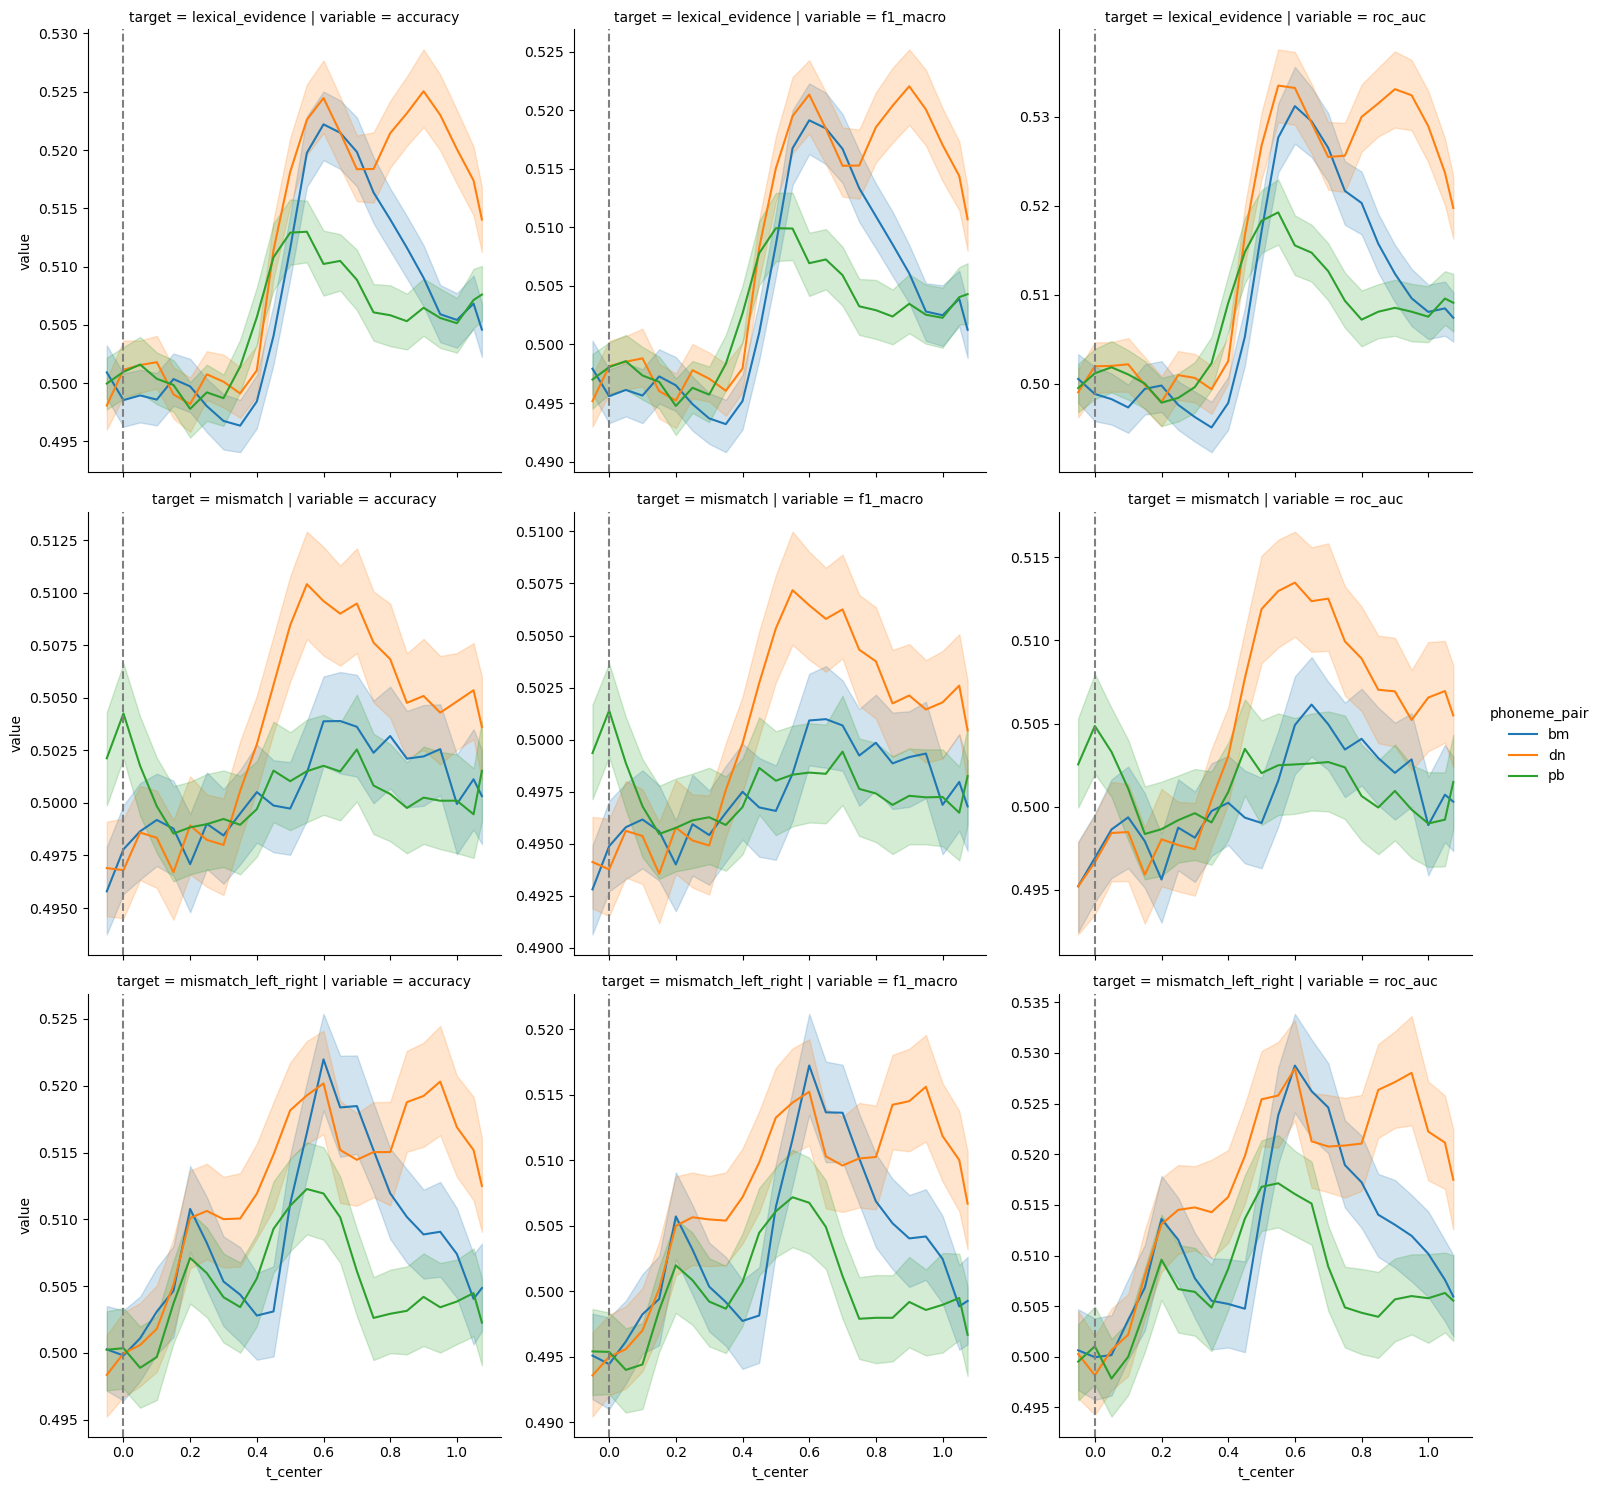

In [10]:
g = sns.relplot(data=scores_avg.reset_index(), x="t_center", y="value", hue="phoneme_pair", row="target", col="variable",
                kind="line", facet_kws={"sharey": False})
for ax in g.axes.flat:
    ax.axvline(0, color="gray", linestyle="--")

In [11]:
# results = torch.load("outputs/single_electrode_decoding/outcomes.pt")

## Prepare performance timecourses

In [12]:
from matplotlib import transforms


def cluster_and_plot(coefs, coef_ids, target_phoneme_pair,
                     plot_times,
                     global_pca, scores_by_site,
                     n_clusters=4,
                     use_global_pca=True):
    assert len(plot_times) == coefs.shape[1]

    select_idxs = np.array([i for i, (_, _, phoneme_pair) in enumerate(coef_ids)
                            if phoneme_pair == target_phoneme_pair])
    coefs = coefs[select_idxs]
    coef_ids = [coef_ids[i] for i in select_idxs]

    if use_global_pca:
        pca = global_pca
        coefs_pca = global_pca.transform(coefs)
    else:
        pca = PCA(n_components=8)
        coefs_pca = pca.fit_transform(coefs)
    print(f"PCA explained variance: {pca.explained_variance_ratio_}")

    km = KMeans(n_clusters=n_clusters, n_init=5)
    km.fit(coefs_pca)
    print(pd.Series(km.labels_).value_counts().sort_index())

    tg_files = sorted([(int(re.findall(r"_(\d+)\.TextGrid", p.name)[0].lstrip("0")), p) for p in Path(tg_dir).glob("*.TextGrid")
                       if target_phoneme_pair in p.stem])
    # Take first and last stimulus == opposite ends of spectrum
    tg_files = [tg_files[0][1], tg_files[-1][1]]
    tgs = [textgrid.TextGrid.fromFile(tg_file) for tg_file in tg_files]
    
    ####

    # # plt.scatter(all_coefs_pca[:, 0], all_coefs_pca[:, 1], c=km.labels_)
    # f, ax = plt.subplots(figsize=(6, 6))
    # for cluster_idx in range(km.n_clusters):
    #     plt.scatter(coefs_pca[km.labels_ == cluster_idx, 0], coefs_pca[km.labels_ == cluster_idx, 1],
    #                 label=f"Cluster {cluster_idx}")
    # plt.legend()

    ####

    # f, ax = plt.subplots(figsize=(8, 4))
    # for pc in range(4):
    #     ax.plot(window_plot_times, pca.components_[pc], label=f"PC {pc}")
    # # plot POD line
    # ax.axvline(POD_dict[target_phoneme_pair], color="gray", linestyle="--")
    # ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1))

    # y_offset = 0
    # for tg in tgs:
    #     intervals = [interval for interval in tg.tiers[0].intervals
    #                  if interval.mark is not None and interval.mark.strip()]
    #     for i, interval in enumerate(intervals):
    #         if interval.mark is None or not interval.mark.strip():
    #                 continue
    #         ax.axvline(interval.minTime, linestyle="--", alpha=0.5, color="salmon")
    #         ax.text(interval.minTime, 0.025 + y_offset, interval.mark.strip(), rotation=90,
    #                 ha="right", va="bottom",
    #                 transform=transforms.blended_transform_factory(ax.transData, ax.transAxes))
            
    #         if i == len(intervals) - 1:
    #             # plot offset as well.
    #             ax.axvline(interval.maxTime, linestyle="--", alpha=0.5, color="blue")
            
    #     y_offset += 0.07

    ####

    cluster_df = pd.DataFrame([
        {"subject": subject, "electrode_idx": electrode_idx, "phoneme_pair": phoneme_pair,
         "cluster": cluster_idx,
         **{f"pca_{j}": pca_val for j, pca_val in enumerate(coefs_pca[i])}}
        for i, ((subject, electrode_idx, phoneme_pair), cluster_idx) in enumerate(zip(coef_ids, km.labels_))
    ])
    cluster_df = pd.merge(cluster_df, scores_by_site,
                          left_on=["subject", "electrode_idx", "phoneme_pair"],
                          right_index=True)
    cluster_avg_performance = cluster_df.groupby("cluster").value.mean()
    cluster_plot_order = cluster_avg_performance.sort_values(ascending=False).index
    cluster_sizes = cluster_df.groupby("cluster").size()

    ####

    n_cols = 2
    n_rows = (n_clusters + n_cols - 1) // n_cols

    f, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))

    for i, (ax, cluster_idx) in enumerate(zip(axes.ravel(), cluster_plot_order)):
        cluster_idxs = km.labels_ == cluster_idx
        cluster_series = coefs[cluster_idxs]

        # resort based on position of peak
        cluster_series = cluster_series[np.argsort(cluster_series.argmax(axis=1))]

        cluster_series = pd.DataFrame(cluster_series)
        cluster_series.columns = np.round(plot_times, 2)
        sns.heatmap(cluster_series, ax=ax, cmap="coolwarm",
                    center=0.5, cbar=i % n_cols == n_cols - 1)
        ax.set_title(f"Cluster {cluster_idx} ({cluster_sizes.loc[cluster_idx]}, {cluster_avg_performance.loc[cluster_idx]:.2f})")
        # remove yticks
        ax.set_yticks([])

    ####

    n_cols = 2
    n_rows = (n_clusters + n_cols - 1) // n_cols

    f, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))

    for ax, cluster_idx in zip(axes.ravel(), cluster_plot_order):
        cluster_idxs = km.labels_ == cluster_idx
        cluster_series = coefs[cluster_idxs]

        ax.plot(plot_times, cluster_series.mean(axis=0), linewidth=3, color="black")
        ax.set_title(f"Cluster {cluster_idx} ({cluster_sizes.loc[cluster_idx]}, {cluster_avg_performance.loc[cluster_idx]:.2f})")

        y_offset = 0
        for tg in tgs:
            intervals = [interval for interval in tg.tiers[0].intervals
                        if interval.mark is not None and interval.mark.strip()]
            for i, interval in enumerate(intervals):
                if interval.mark is None or not interval.mark.strip():
                        continue
                ax.axvline(interval.minTime, linestyle="--", alpha=0.5, color="salmon")
                ax.text(interval.minTime, 0.025 + y_offset, interval.mark.strip(), rotation=90,
                        ha="right", va="bottom",
                        transform=transforms.blended_transform_factory(ax.transData, ax.transAxes))
                
                if i == len(intervals) - 1:
                    # plot offset as well.
                    ax.axvline(interval.maxTime, linestyle="--", alpha=0.5, color="blue")
                
            y_offset += 0.07

        plot_sample = np.random.choice(cluster_series.shape[0], 10)
        for i in plot_sample:
            ax.plot(plot_times, cluster_series[i], alpha=0.3)

    ret = cluster_df
    ret["cluster"] = ret.cluster.astype(str)
    return ret    

In [13]:
def analyze_target(target, metric="roc_auc"):
    # For each target, sample the top percentile of electrodes on the given metric
    scores_by_site = scores_avg.query("target == @target and variable == @metric") \
        .groupby(["subject", "electrode_idx", "phoneme_pair"]).value.max()
    study_sites = scores_by_site[scores_by_site > np.percentile(scores_by_site, score_percentile_threshold)].index

    scores_avg_lex = scores_avg.query("target == @target")

    # for the selected electrodes, compute timecourses of decoding performance
    perf_series = scores_avg_lex.query("variable == @metric") \
        .set_index(["subject", "electrode_idx", "phoneme_pair"]).loc[study_sites] \
        .set_index(["smin", "smax"], append=True) \
        .sort_index() \
        .groupby(["subject", "electrode_idx", "phoneme_pair"]) \
        .apply(lambda x: x.value.values)

    perf_series_ids, perf_series = perf_series.index, np.stack(perf_series.values)

    global_pca = PCA(n_components=6)
    global_pca.fit(perf_series)

    window_plot_times = sorted(scores_avg_lex.t_center.unique())
    assert len(window_plot_times) == perf_series.shape[1]

    results = {}
    for phoneme_pair in study_sites.get_level_values("phoneme_pair").unique():
        print("Phoneme pair:", phoneme_pair)
        results[phoneme_pair] = cluster_and_plot(perf_series, perf_series_ids, phoneme_pair,
                                                 window_plot_times,
                                                 global_pca, scores_by_site,
                                                 n_clusters=4, use_global_pca=True)
    # combine results
    results = pd.concat(results.values())
    results = results.reset_index(drop=True)
    results["target"] = target
    results["metric"] = metric

    return results

In [98]:
def plot_target_response(target, target_phoneme_pair, sites, metric="roc_auc"):
    # for the selected electrodes, compute timecourses of decoding performance
    perf_series = scores_avg.query("target == @target and variable == @metric") \
        .set_index(["subject", "electrode_idx", "phoneme_pair"]).loc[sites] \
        .set_index(["smin", "smax"], append=True) \
        .sort_index() \
        .groupby(["subject", "electrode_idx", "phoneme_pair"]) \
        .apply(lambda x: x.value.values)
    
    perf_series_ids, perf_series = perf_series.index, np.stack(perf_series.values)

    window_plot_times = sorted(scores_avg.t_center.unique())
    assert len(window_plot_times) == perf_series.shape[1]

    ####

    tg_files = sorted([(int(re.findall(r"_(\d+)\.TextGrid", p.name)[0].lstrip("0")), p)
                       for p in Path(tg_dir).glob("*.TextGrid")
                       if target_phoneme_pair in p.stem])
    # Take first and last stimulus == opposite ends of spectrum
    tg_files = [tg_files[0][1], tg_files[-1][1]]
    tgs = [textgrid.TextGrid.fromFile(tg_file) for tg_file in tg_files]

    ####

    f, ax = plt.subplots(figsize=(7, 3))

    ys = perf_series

    ax.plot(window_plot_times, ys.mean(axis=0), linewidth=3, color="black")
    ax.set_title(f"{len(ys)} electrodes, {target_phoneme_pair}")

    y_offset = 0
    for tg in tgs:
        intervals = [interval for interval in tg.tiers[0].intervals
                    if interval.mark is not None and interval.mark.strip()]
        for i, interval in enumerate(intervals):
            if interval.mark is None or not interval.mark.strip():
                    continue
            ax.axvline(interval.minTime, linestyle="--", alpha=0.5, color="salmon")
            ax.text(interval.minTime, 0.025 + y_offset, interval.mark.strip(), rotation=90,
                    ha="right", va="bottom",
                    transform=transforms.blended_transform_factory(ax.transData, ax.transAxes))
            
            if i == len(intervals) - 1:
                # plot offset as well.
                ax.axvline(interval.maxTime, linestyle="--", alpha=0.5, color="blue")
            
        y_offset += 0.07

    plot_sample = ys
    for i in range(len(plot_sample)):
        ax.plot(window_plot_times, ys[i], alpha=0.3)

In [14]:
all_cluster_results_arr = []

Phoneme pair: dn
PCA explained variance: [0.28246462 0.1922474  0.1256512  0.07407715 0.06117986 0.0427855 ]
0    52
1    26
2    58
3    24
Name: count, dtype: int64
Phoneme pair: bm
PCA explained variance: [0.28246462 0.1922474  0.1256512  0.07407715 0.06117986 0.0427855 ]
0    32
1    36
2    10
3    16
Name: count, dtype: int64
Phoneme pair: pb
PCA explained variance: [0.28246462 0.1922474  0.1256512  0.07407715 0.06117986 0.0427855 ]
0    16
1    13
2    17
3    23
Name: count, dtype: int64


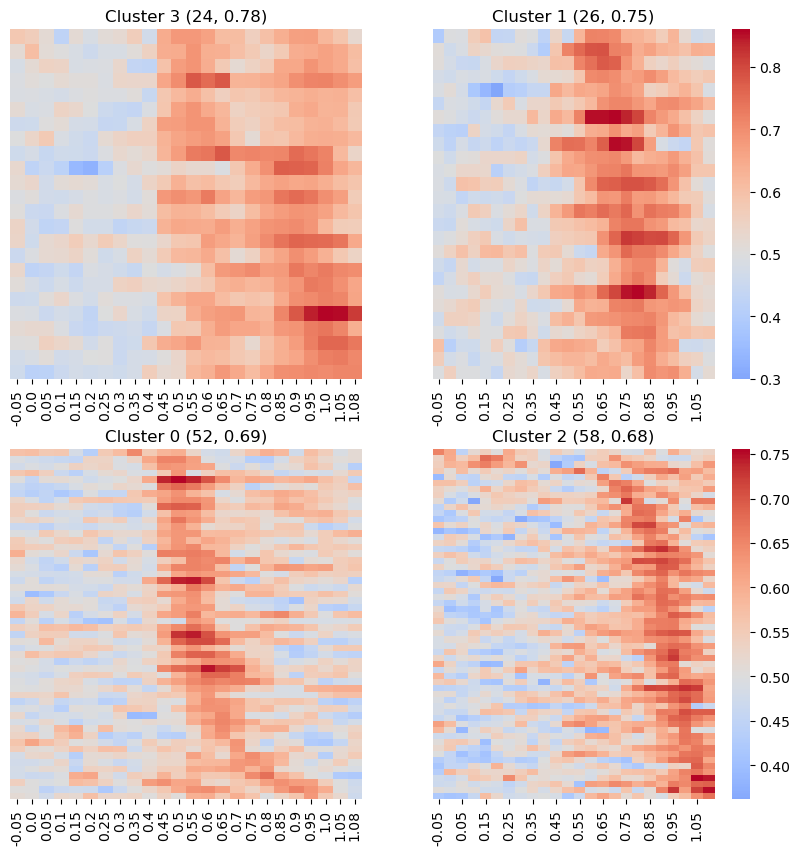

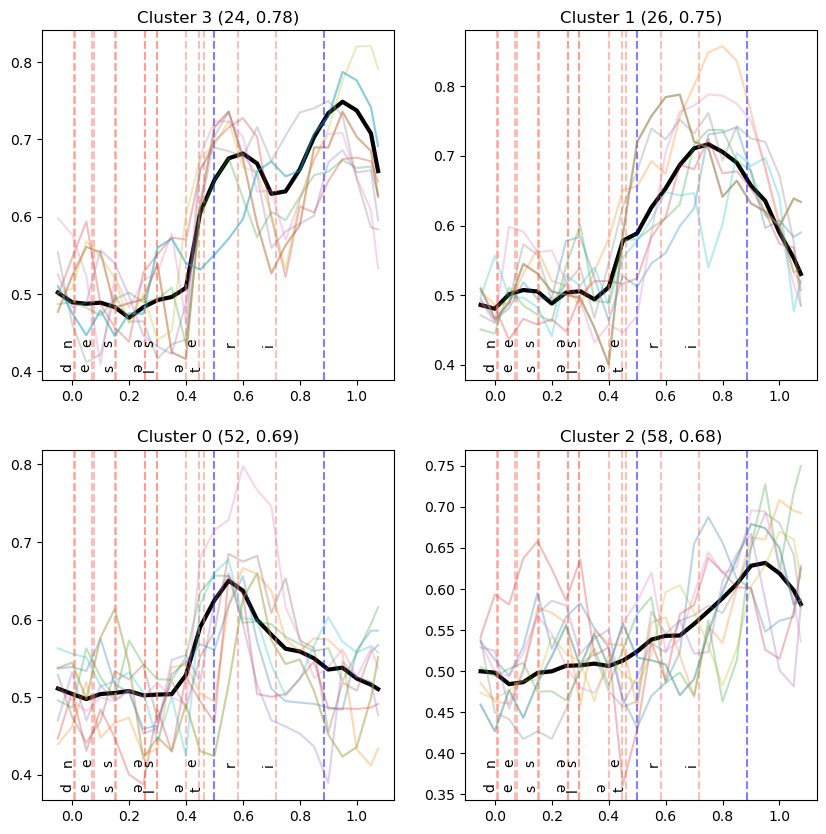

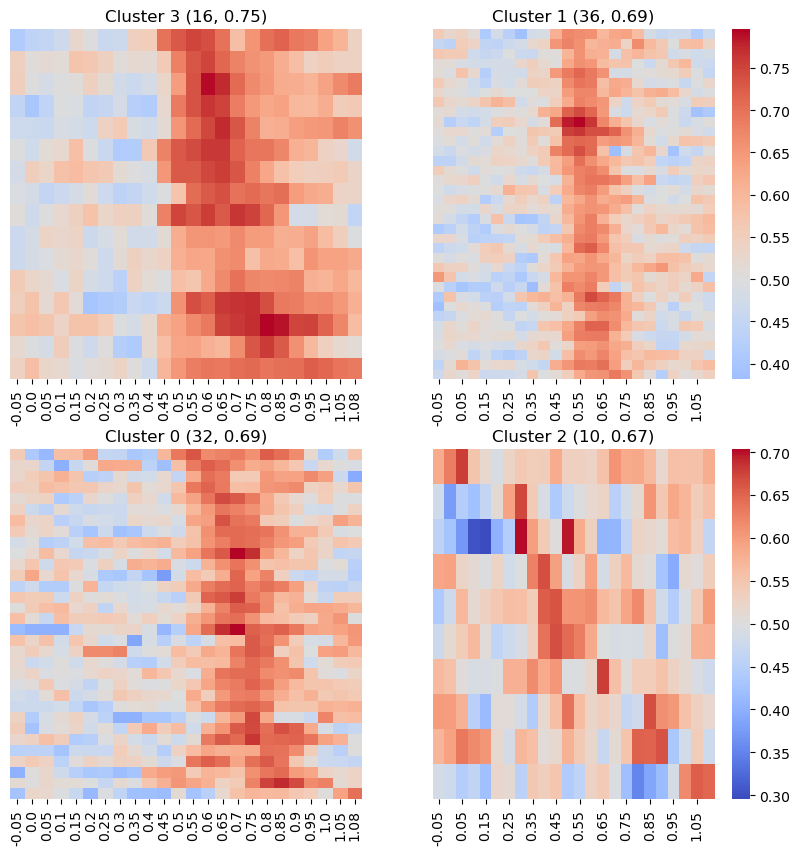

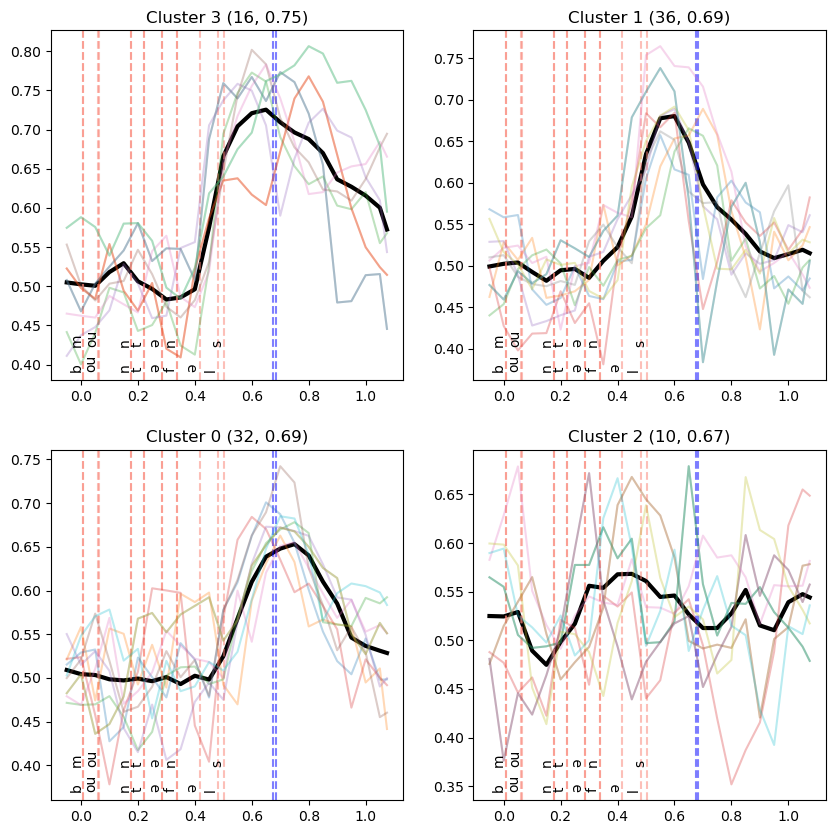

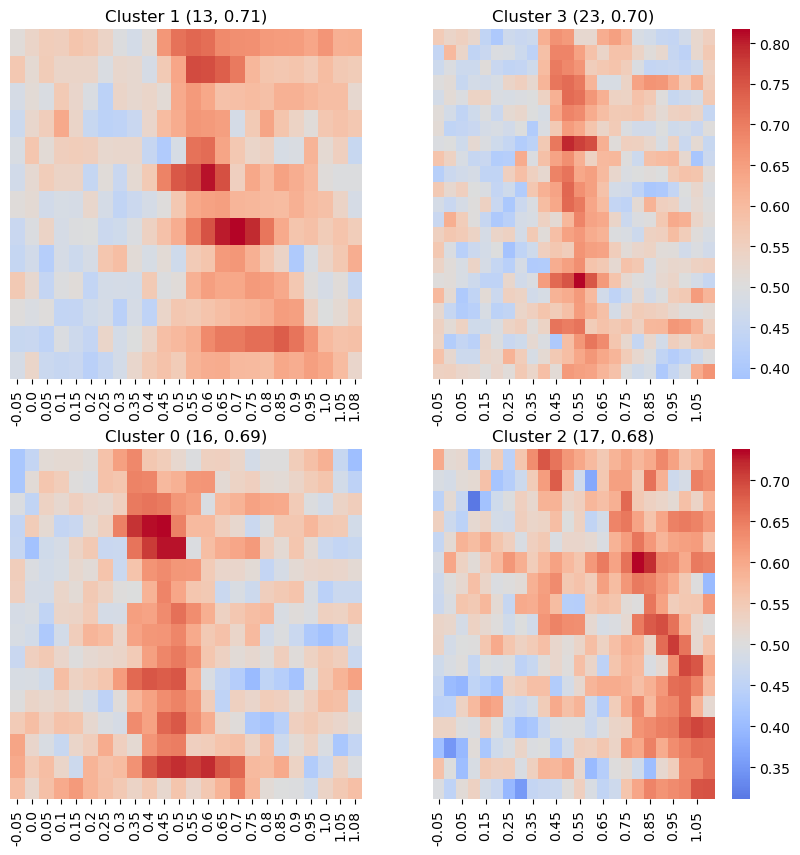

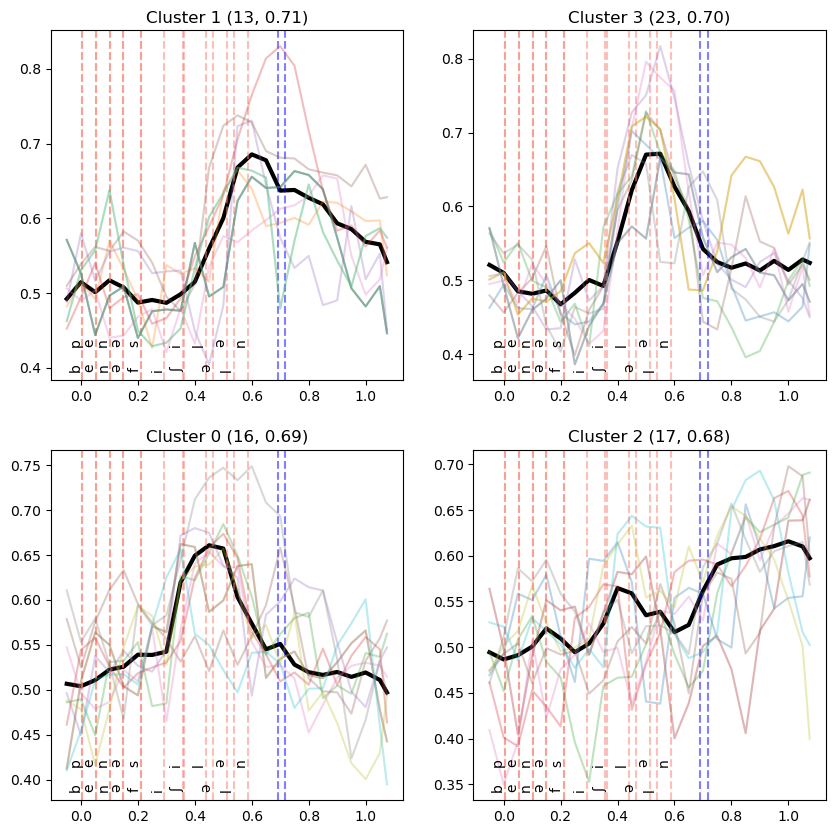

In [15]:
all_cluster_results_arr.append(analyze_target("lexical_evidence"))

Phoneme pair: dn
PCA explained variance: [0.22217753 0.1254773  0.09442663 0.08220119 0.07604482 0.06356667]
0    45
1    36
2    21
3    42
Name: count, dtype: int64
Phoneme pair: pb
PCA explained variance: [0.22217753 0.1254773  0.09442663 0.08220119 0.07604482 0.06356667]
0    28
1    22
2    24
3    27
Name: count, dtype: int64
Phoneme pair: bm
PCA explained variance: [0.22217753 0.1254773  0.09442663 0.08220119 0.07604482 0.06356667]
0    19
1    20
2    21
3    18
Name: count, dtype: int64


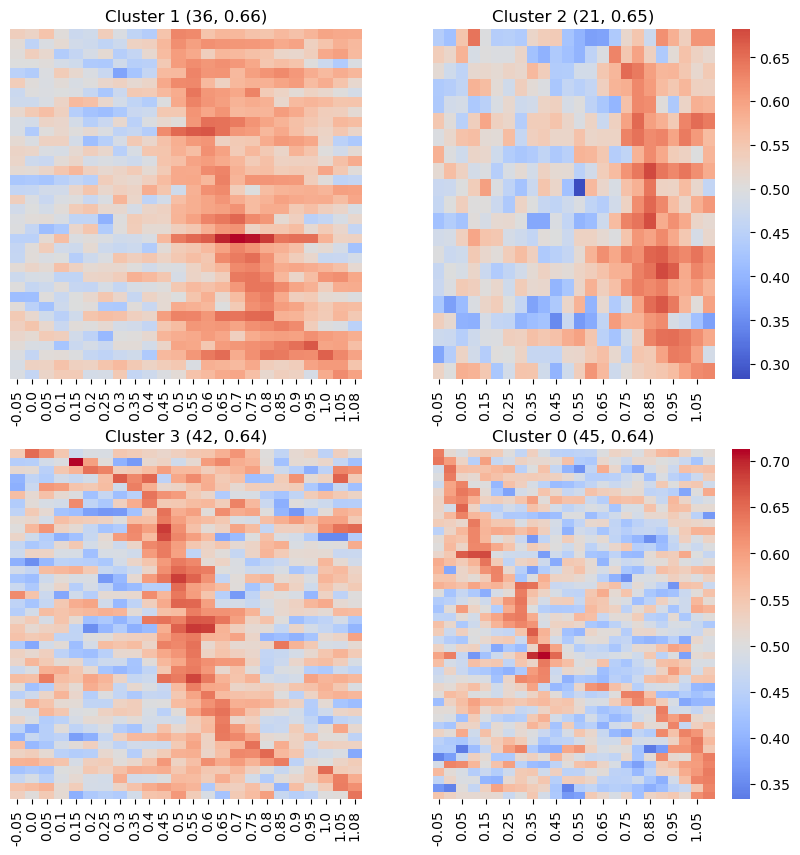

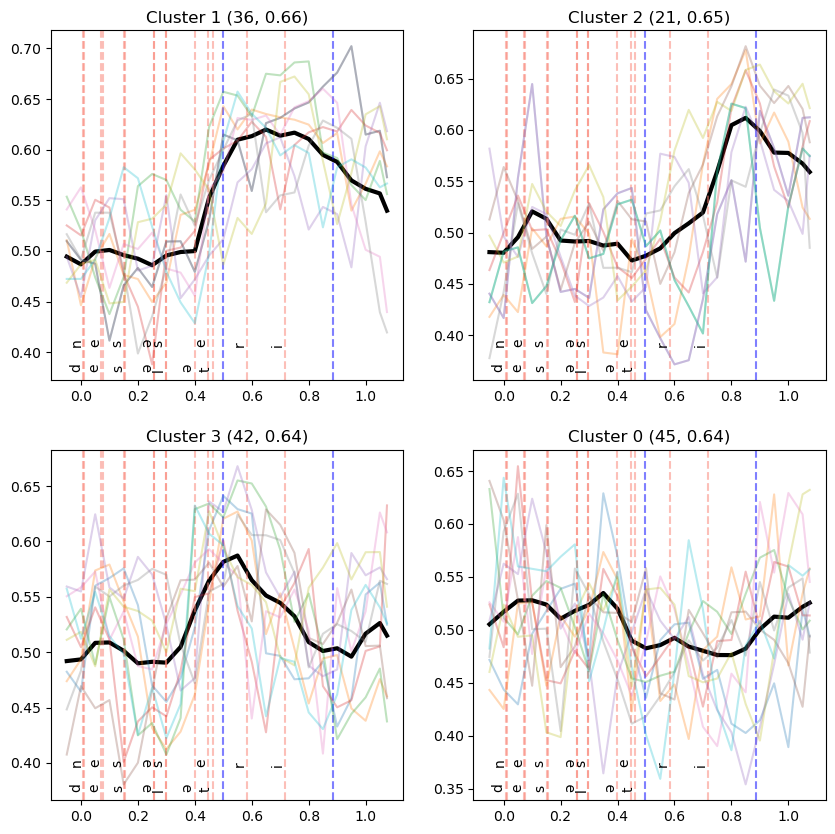

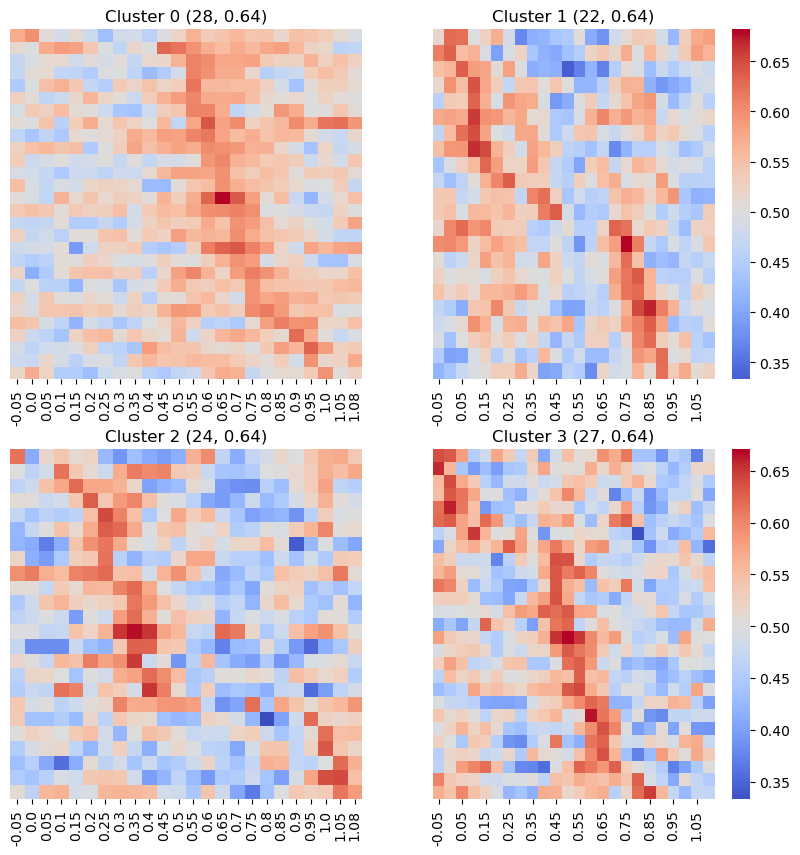

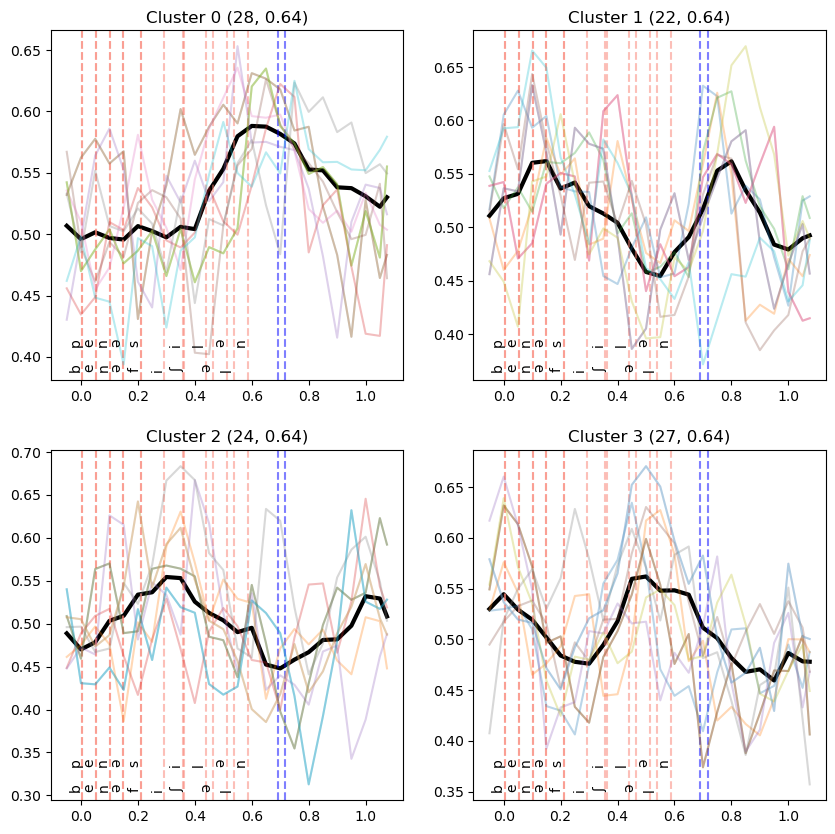

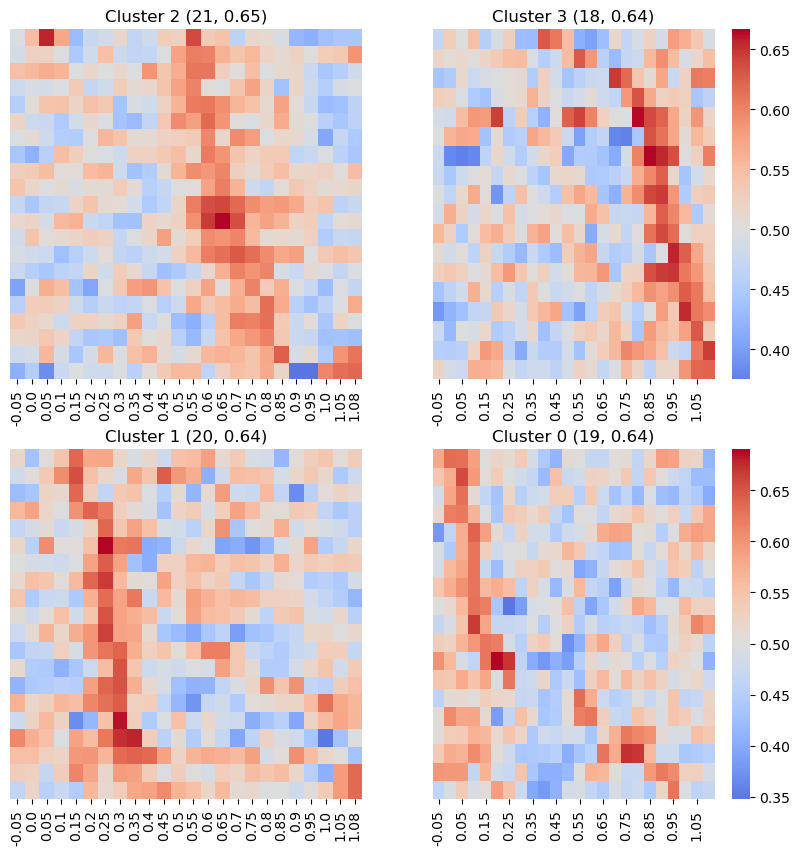

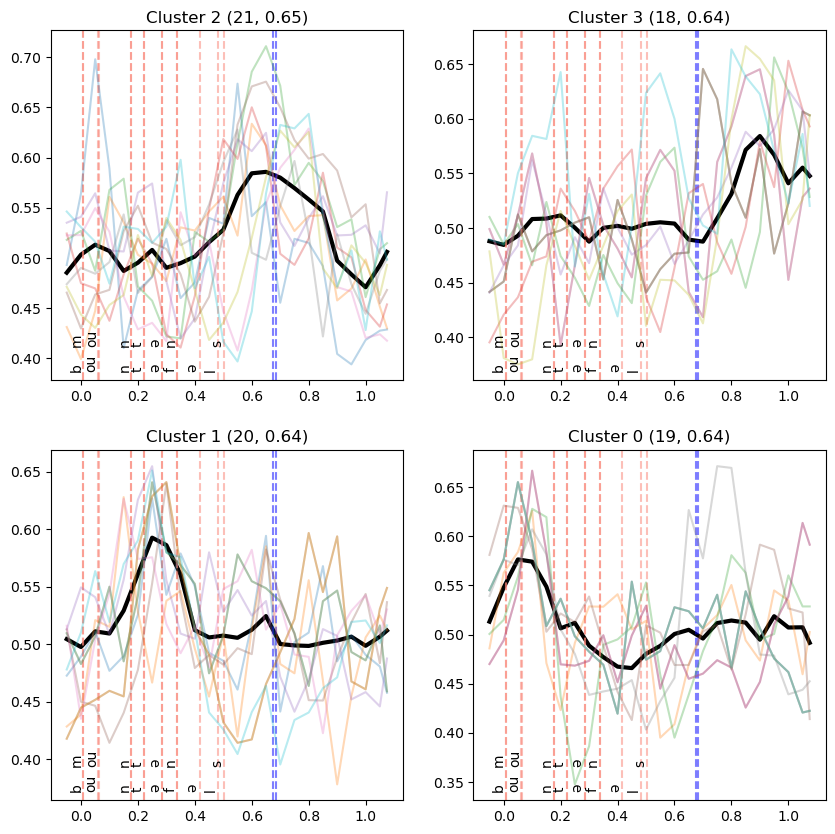

In [16]:
all_cluster_results_arr.append(analyze_target("mismatch"))

Phoneme pair: pb
PCA explained variance: [0.21741206 0.17286734 0.13036152 0.08909872 0.06724392 0.05792842]
0    15
1    15
2    16
3    14
Name: count, dtype: int64
Phoneme pair: dn
PCA explained variance: [0.21741206 0.17286734 0.13036152 0.08909872 0.06724392 0.05792842]
0    50
1    35
2    35
3    37
Name: count, dtype: int64
Phoneme pair: bm
PCA explained variance: [0.21741206 0.17286734 0.13036152 0.08909872 0.06724392 0.05792842]
0    18
1    25
2    39
3    23
Name: count, dtype: int64


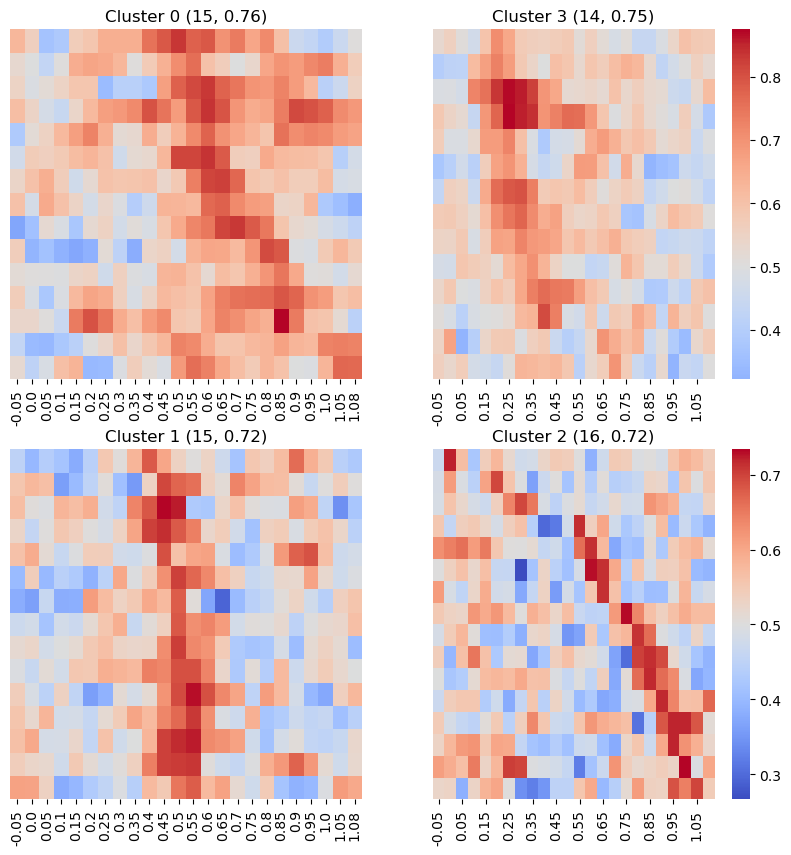

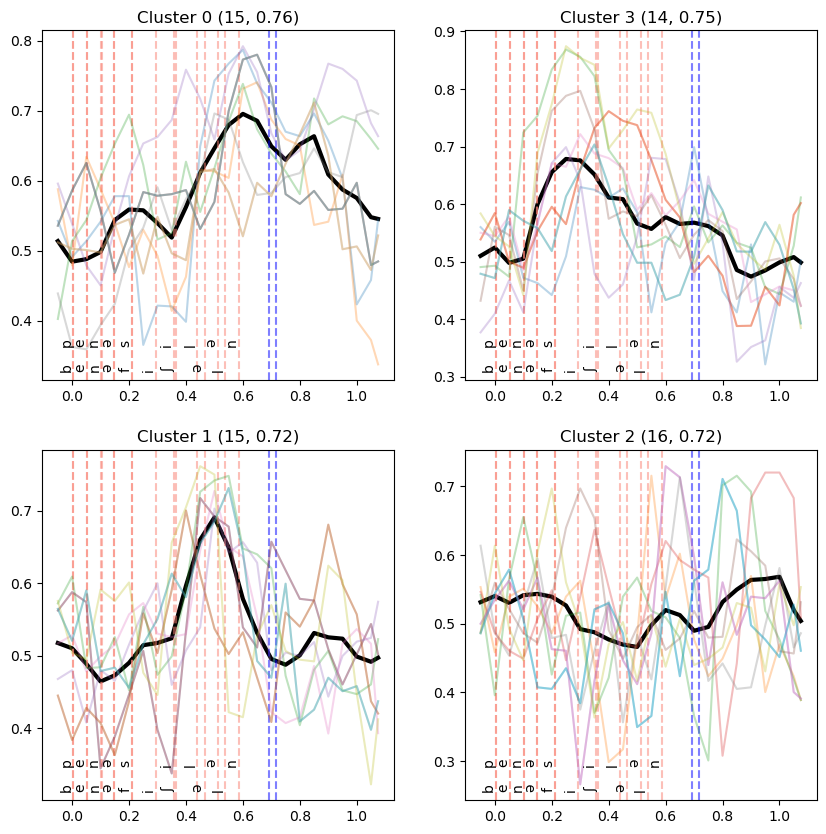

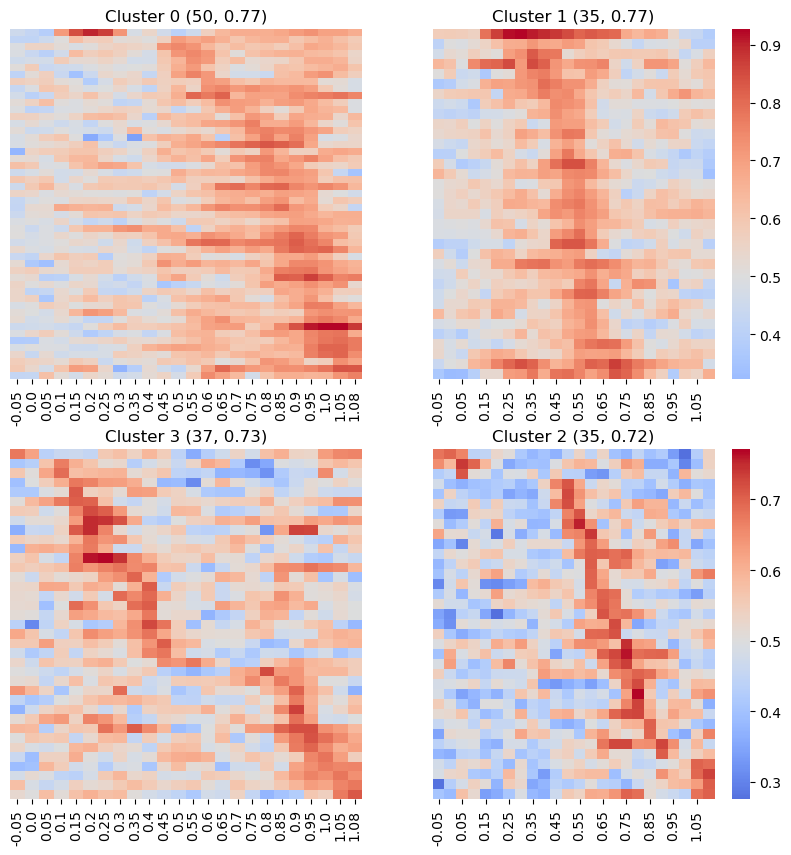

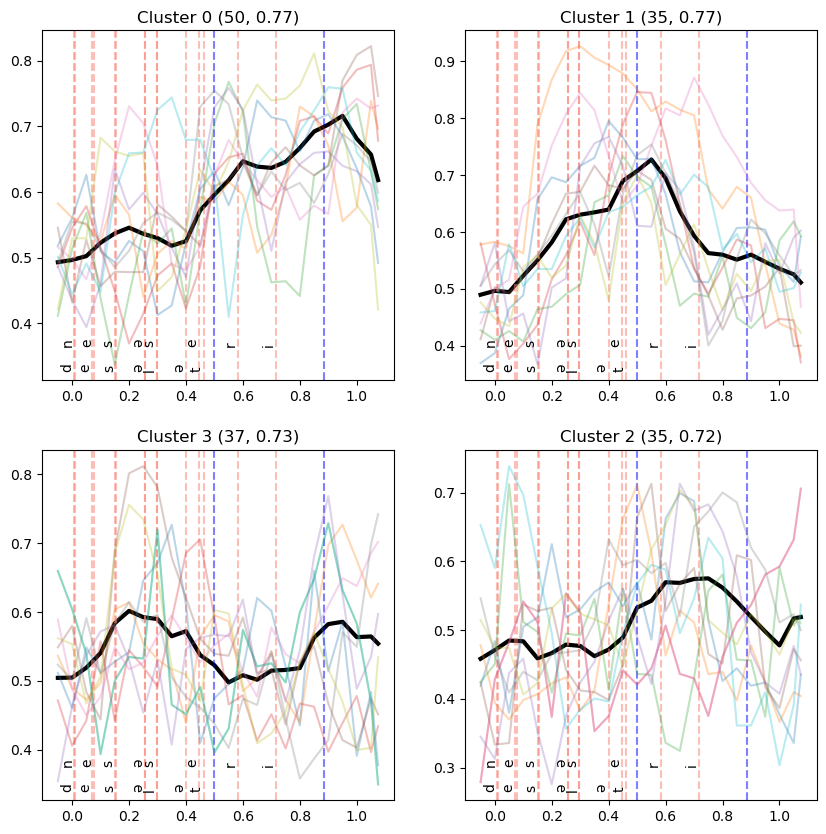

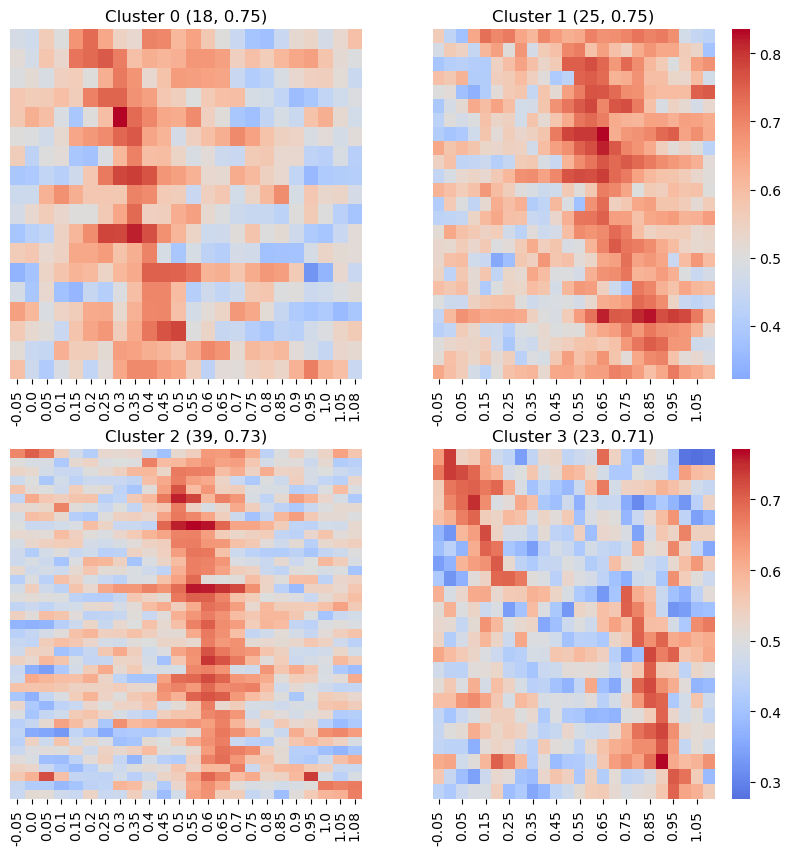

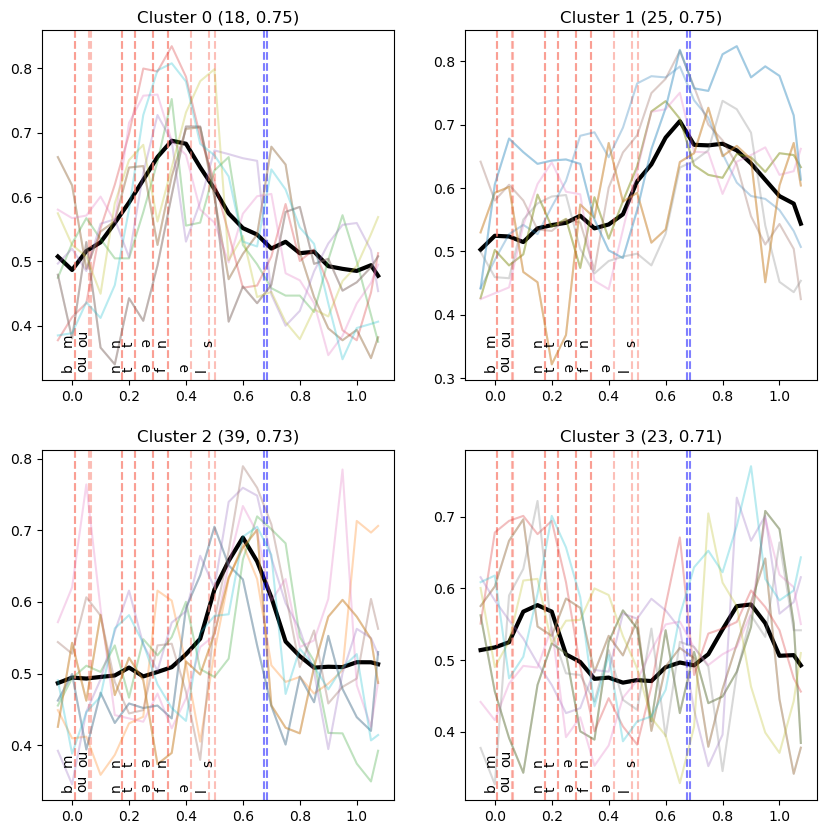

In [17]:
all_cluster_results_arr.append(analyze_target("mismatch_left_right"))

## Prepare coefficients

This section uses the old method of comparing beta weights across encoders using the entire time series to predict binary labels.

In [18]:
# coef_ids = [
#     (subject, electrode_idx, phoneme_pair, smin, smax, fold_idx)
#     for subject, electrode_idx, phoneme_pair, smin, smax in results["models"].keys()
#     for fold_idx in range(len(results["models"][subject, electrode_idx, phoneme_pair, smin, smax]))
#     if (subject, electrode_idx, phoneme_pair, smin, smax) in study_scores.index
# ]

In [19]:
# coef_ids = [
#     (subject, electrode_idx, phoneme_pair)
#     for subject, electrode_idx, phoneme_pair in results["models"].keys()
#     if (subject, electrode_idx, phoneme_pair) in study_scores.index
# ]

# num_folds = len(next(iter(results["models"])))

# all_coefs = np.array([
#     [results["models"][subject, electrode_idx, phoneme_pair][fold_idx].steps[-1][1].coef_.squeeze()
#      for fold_idx in folds]
#     for subject, electrode_idx, phoneme_pair in coef_ids
# ])

# # take mean over electrodes
# all_coefs = all_coefs.mean(axis=1)

In [20]:
# all_coefs_norm = all_coefs / np.abs(all_coefs).max(1, keepdims=True)

In [21]:
# global_pca = PCA(n_components=8)
# global_pca.fit(all_coefs_norm)

In [22]:
# from matplotlib import transforms


# def cluster_and_plot(coefs, coef_ids, target_phoneme_pair, n_clusters=4,
#                      use_global_pca=True):
#     select_idxs = np.array([i for i, (_, _, phoneme_pair) in enumerate(coef_ids)
#                             if phoneme_pair == target_phoneme_pair])
#     coefs = coefs[select_idxs]
#     coef_ids = [coef_ids[i] for i in select_idxs]

#     if use_global_pca:
#         pca = global_pca
#         coefs_pca = global_pca.transform(coefs)
#     else:
#         pca = PCA(n_components=8)
#         coefs_pca = pca.fit_transform(coefs)
#     print(f"PCA explained variance: {pca.explained_variance_ratio_}")

#     km = KMeans(n_clusters=n_clusters, n_init=5)
#     km.fit(coefs_pca)
#     print(pd.Series(km.labels_).value_counts().sort_index())


#     tg_file = next(p for p in Path(tg_dir).glob("*.TextGrid") if target_phoneme_pair in p.stem)
#     tg = textgrid.TextGrid.fromFile(tg_file)
    
#     ####

#     # plt.scatter(all_coefs_pca[:, 0], all_coefs_pca[:, 1], c=km.labels_)
#     f, ax = plt.subplots(figsize=(6, 6))
#     for cluster_idx in range(km.n_clusters):
#         plt.scatter(coefs_pca[km.labels_ == cluster_idx, 0], coefs_pca[km.labels_ == cluster_idx, 1],
#                     label=f"Cluster {cluster_idx}")
#     plt.legend()

#     ####

#     f, ax = plt.subplots(figsize=(8, 4))
#     for pc in range(4):
#         ax.plot(plot_times, pca.components_[pc], label=f"PC {pc}")
#     ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1))

#     for interval in tg.tiers[0].intervals:
#         if interval.mark is None or not interval.mark.strip():
#                 continue
#         ax.axvline(interval.minTime, linestyle="--", alpha=0.5, color="salmon")
#         ax.text(interval.minTime, 0.025, interval.mark.strip(), rotation=90,
#                 ha="right", va="bottom",
#                 transform=transforms.blended_transform_factory(ax.transData, ax.transAxes))

#     ####

#     cluster_df = pd.DataFrame([
#         {"subject": subject, "electrode_idx": electrode_idx, "phoneme_pair": phoneme_pair,
#          "cluster": cluster_idx,
#          **{f"pca_{j}": pca_val for j, pca_val in enumerate(coefs_pca[i])}}
#         for i, ((subject, electrode_idx, phoneme_pair), cluster_idx) in enumerate(zip(coef_ids, km.labels_))
#     ])
#     cluster_df = pd.merge(cluster_df, scores_avg,
#                           left_on=["subject", "electrode_idx", "phoneme_pair"],
#                           right_index=True)
#     cluster_avg_performance = cluster_df.groupby("cluster").roc_auc.mean()
#     cluster_plot_order = cluster_avg_performance.sort_values(ascending=False).index
#     cluster_sizes = cluster_df.groupby("cluster").size()

#     ####

#     n_cols = 2
#     n_rows = (n_clusters + n_cols - 1) // n_cols

#     f, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))

#     for i, (ax, cluster_idx) in enumerate(zip(axes.ravel(), cluster_plot_order)):
#         cluster_idxs = km.labels_ == cluster_idx
#         cluster_series = coefs[cluster_idxs]

#         # resort based on position of peak
#         cluster_series = cluster_series[np.argsort(cluster_series.argmax(axis=1))]

#         sns.heatmap(cluster_series, ax=ax, cmap="coolwarm", center=0, cbar=i % n_cols == n_cols - 1)
#         ax.set_title(f"Cluster {cluster_idx} ({cluster_sizes.loc[cluster_idx]}, {cluster_avg_performance.loc[cluster_idx]:.2f})")
#         # remove yticks
#         ax.set_yticks([])

#     ####

#     n_cols = 2
#     n_rows = (n_clusters + n_cols - 1) // n_cols

#     f, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))

#     for ax, cluster_idx in zip(axes.ravel(), cluster_plot_order):
#         cluster_idxs = km.labels_ == cluster_idx
#         cluster_series = coefs[cluster_idxs]

#         ax.plot(plot_times, cluster_series.mean(axis=0), linewidth=3, color="black")
#         ax.set_title(f"Cluster {cluster_idx} ({cluster_sizes.loc[cluster_idx]}, {cluster_avg_performance.loc[cluster_idx]:.2f})")

#         for interval in tg.tiers[0].intervals:
#             if interval.mark is None or not interval.mark.strip():
#                     continue
#             ax.axvline(interval.minTime, linestyle="--", alpha=0.5, color="salmon")
#             ax.text(interval.minTime, 0.025, interval.mark.strip(), rotation=90,
#                     ha="right", va="bottom",
#                     transform=transforms.blended_transform_factory(ax.transData, ax.transAxes))

#         plot_sample = np.random.choice(cluster_series.shape[0], 10)
#         for i in plot_sample:
#             ax.plot(plot_times, cluster_series[i], alpha=0.3)

#     ret = cluster_df
#     ret["cluster"] = ret.cluster.astype(str)
#     return ret    

In [23]:
# results_bm = cluster_and_plot(all_coefs_norm, coef_ids, "bm")

In [24]:
# results_pb = cluster_and_plot(all_coefs_norm, coef_ids, "pb")

In [25]:
# results_dn = cluster_and_plot(all_coefs_norm, coef_ids, "dn")

## Merge

In [26]:
all_cluster_results = pd.concat(all_cluster_results_arr)

In [27]:
all_cluster_results.groupby(["phoneme_pair", "cluster"]).value.mean().sort_values()

phoneme_pair  cluster
pb            2          0.672390
              1          0.684198
              3          0.684606
              0          0.686064
dn            2          0.687415
bm            0          0.690671
              2          0.695804
              1          0.697647
dn            0          0.700478
bm            3          0.701982
dn            3          0.702412
              1          0.723571
Name: value, dtype: float64

In [28]:
all_cluster_results

,subject,electrode_idx,phoneme_pair,cluster,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,value,target,metric
0,EC243,68,dn,0,-0.136109,0.086176,-0.048842,-0.120820,-0.026289,0.095792,0.669126,lexical_evidence,roc_auc
1,EC243,70,dn,0,-0.235027,-0.043109,-0.043674,-0.054777,0.033990,0.007891,0.658854,lexical_evidence,roc_auc
2,EC243,89,dn,0,-0.257110,0.258186,-0.059207,-0.076651,0.024466,-0.132793,0.728299,lexical_evidence,roc_auc
3,EC243,92,dn,2,0.073634,-0.122135,-0.050169,0.084790,-0.095826,-0.040751,0.676215,lexical_evidence,roc_auc
4,EC243,93,dn,2,0.055268,-0.204163,-0.041512,0.074657,-0.060276,-0.034734,0.656105,lexical_evidence,roc_auc
...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,EC287,106,bm,3,-0.144032,-0.125834,0.190709,0.143679,0.024493,0.151563,0.709635,mismatch_left_right,roc_auc
318,EC287,113,bm,2,-0.056725,-0.140047,-0.083588,0.074708,-0.233194,-0.106430,0.746094,mismatch_left_right,roc_auc
319,EC287,157,bm,3,-0.329664,-0.032401,0.149761,0.086035,-0.081072,0.258934,0.696615,mismatch_left_right,roc_auc
320,EC287,188,bm,3,-0.270400,-0.027418,0.119288,-0.116466,-0.234470,0.103469,0.736979,mismatch_left_right,roc_auc


In [51]:
explore = all_cluster_results[~all_cluster_results.cluster.isna()].astype({"cluster": int}).pivot_table(index=["subject", "electrode_idx", "phoneme_pair"], columns=["target"], values=["cluster"])
explore.columns = explore.columns.droplevel(0)

In [56]:
explore.xs("pb", level="phoneme_pair").query("mismatch_left_right == 3")

target                 lexical_evidence  mismatch  mismatch_left_right
subject electrode_idx                                                 
EC248   360                         NaN       NaN                  3.0
        382                         0.0       NaN                  3.0
EC250   215                         3.0       0.0                  3.0
        216                         NaN       NaN                  3.0
EC253   21                          3.0       NaN                  3.0
        181                         NaN       3.0                  3.0
        211                         NaN       3.0                  3.0
EC260   220                         0.0       NaN                  3.0
EC279   186                         NaN       NaN                  3.0
EC282   97                          1.0       NaN                  3.0
        98                          NaN       NaN                  3.0
        106                         3.0       NaN                  3.0
        161                         NaN       2.0                  3.0
EC287   56                          NaN       0.0                  3.0

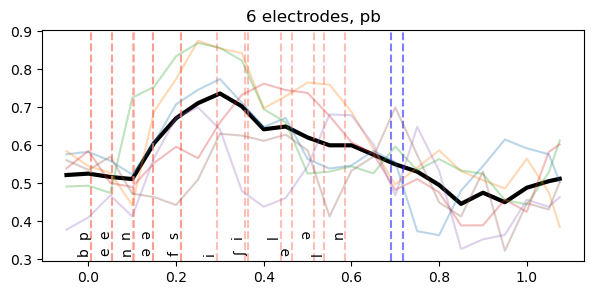

In [103]:
plot_target_response("mismatch_left_right", "pb", explore.xs("pb", level="phoneme_pair", drop_level=False).query("mismatch_left_right == 3 and not lexical_evidence.isnull()").index)

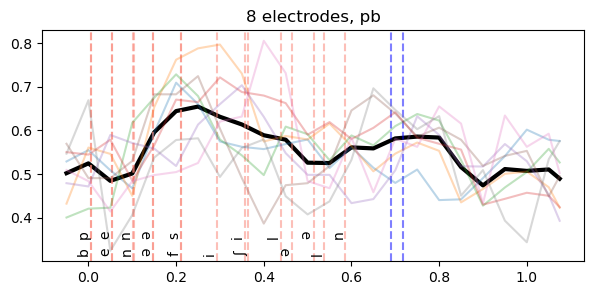

In [104]:
plot_target_response("mismatch_left_right", "pb", explore.xs("pb", level="phoneme_pair", drop_level=False).query("mismatch_left_right == 3 and lexical_evidence.isnull()").index)

In [87]:
explore.xs("dn", level="phoneme_pair").query("mismatch_left_right == 1")

target                 lexical_evidence  mismatch  mismatch_left_right
subject electrode_idx                                                 
EC243   87                          NaN       1.0                  1.0
        89                          0.0       1.0                  1.0
        102                         1.0       1.0                  1.0
        103                         0.0       1.0                  1.0
EC248   199                         NaN       NaN                  1.0
        341                         NaN       NaN                  1.0
        349                         NaN       NaN                  1.0
        365                         0.0       3.0                  1.0
EC250   185                         0.0       NaN                  1.0
        186                         NaN       1.0                  1.0
        215                         0.0       3.0                  1.0
EC253   3                           0.0       NaN                  1.0
        4                           0.0       3.0                  1.0
        20                          0.0       NaN                  1.0
        21                          1.0       NaN                  1.0
        22                          0.0       NaN                  1.0
        36                          0.0       NaN                  1.0
        37                          0.0       NaN                  1.0
        53                          0.0       NaN                  1.0
        148                         NaN       0.0                  1.0
        192                         NaN       NaN                  1.0
        195                         3.0       NaN                  1.0
        196                         0.0       2.0                  1.0
        197                         0.0       1.0                  1.0
EC260   219                         0.0       1.0                  1.0
EC270   101                         NaN       NaN                  1.0
EC278   28                          NaN       NaN                  1.0
        83                          1.0       NaN                  1.0
        86                          0.0       NaN                  1.0
        102                         0.0       NaN                  1.0
EC282   84                          2.0       0.0                  1.0
        99                          NaN       NaN                  1.0
        101                         2.0       NaN                  1.0
        117                         1.0       0.0                  1.0
        125                         NaN       NaN                  1.0

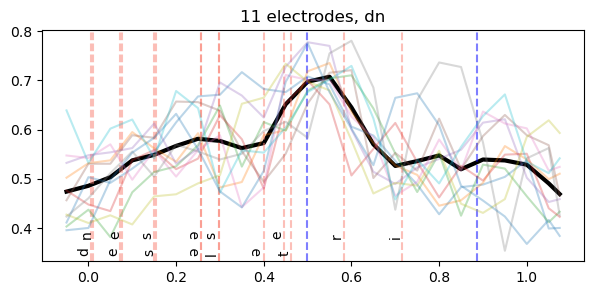

In [99]:
plot_target_response("mismatch_left_right", "dn", explore.xs("dn", level="phoneme_pair", drop_level=False).query("mismatch_left_right == 1 and lexical_evidence.isnull()").index)

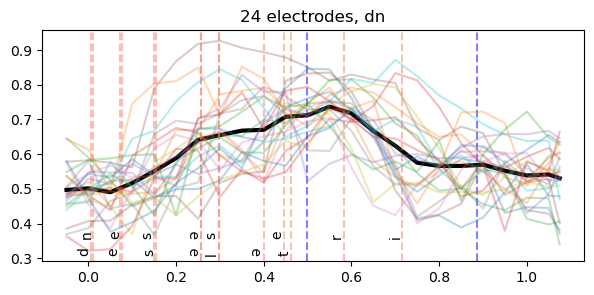

In [100]:
plot_target_response("mismatch_left_right", "dn", explore.xs("dn", level="phoneme_pair", drop_level=False).query("mismatch_left_right == 1 and not lexical_evidence.isnull()").index)

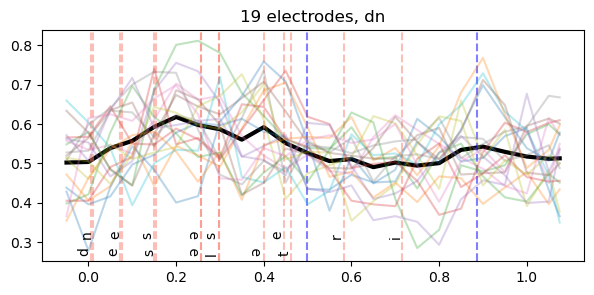

In [107]:
plot_target_response("mismatch_left_right", "dn", explore.xs("dn", level="phoneme_pair", drop_level=False).query("mismatch_left_right == 3 and lexical_evidence.isnull()").index)

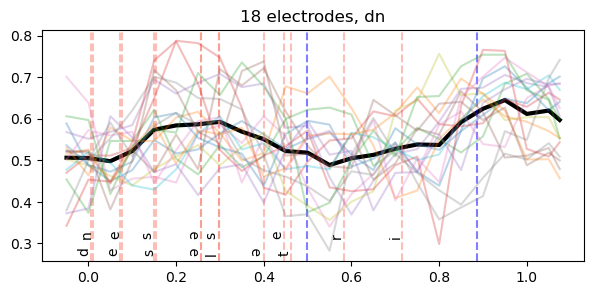

In [108]:
plot_target_response("mismatch_left_right", "dn", explore.xs("dn", level="phoneme_pair", drop_level=False).query("mismatch_left_right == 3 and not lexical_evidence.isnull()").index)

In [113]:
explore

target                              lexical_evidence  mismatch  \
subject electrode_idx phoneme_pair                               
EC243   59            pb                         NaN       NaN   
        68            dn                         0.0       NaN   
        70            bm                         NaN       NaN   
                      dn                         0.0       NaN   
        72            dn                         NaN       1.0   
...                                              ...       ...   
EC287   188           bm                         NaN       NaN   
        190           bm                         NaN       NaN   
                      dn                         NaN       NaN   
        199           bm                         NaN       1.0   
        201           dn                         NaN       3.0   

target                              mismatch_left_right  
subject electrode_idx phoneme_pair                       
EC243   59            pb                            2.0  
        68            dn                            2.0  
        70            bm                            2.0  
                      dn                            NaN  
        72            dn                            NaN  
...                                                 ...  
EC287   188           bm                            3.0  
        190           bm                            2.0  
                      dn                            3.0  
        199           bm                            NaN  
        201           dn                            NaN  

[695 rows x 3 columns]

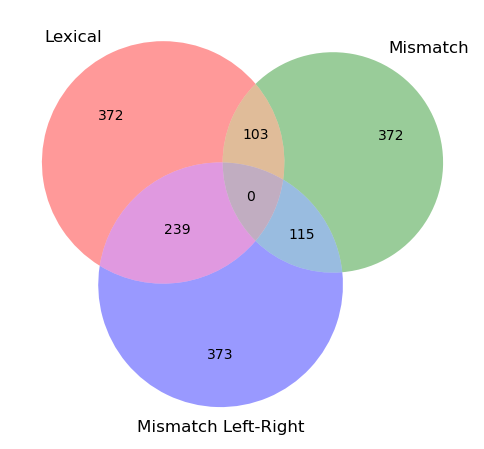

In [114]:
# Convert to boolean masks for null values
lexical_null = explore["lexical_evidence"].isnull()
mismatch_null = explore["mismatch"].isnull()
mismatch_lr_null = explore["mismatch_left_right"].isnull()

# Count occurrences for Venn diagram
set_sizes = {
    "Lexical": lexical_null.sum(),
    "Mismatch": mismatch_null.sum(),
    "Mismatch Left-Right": mismatch_lr_null.sum(),
    "Lexical & Mismatch": (lexical_null & mismatch_null).sum(),
    "Lexical & Mismatch Left-Right": (lexical_null & mismatch_lr_null).sum(),
    "Mismatch & Mismatch Left-Right": (mismatch_null & mismatch_lr_null).sum(),
    "All Three": (lexical_null & mismatch_null & mismatch_lr_null).sum(),
}

# Create the Venn diagram
plt.figure(figsize=(6,6))
from matplotlib_venn import venn3
venn = venn3(subsets=(
    set_sizes["Lexical"], 
    set_sizes["Mismatch"], 
    set_sizes["Lexical & Mismatch"], 
    set_sizes["Mismatch Left-Right"], 
    set_sizes["Lexical & Mismatch Left-Right"], 
    set_sizes["Mismatch & Mismatch Left-Right"], 
    set_sizes["All Three"]
), set_labels=("Lexical", "Mismatch", "Mismatch Left-Right"))

In [29]:
elec_condition_filters = {
    "stack": [
        ("EC243", 102, "bm"),
        ("EC260", 219, "bm"),
        ("EC243", 103, "bm"),
        ("EC243", 103, "pb"),
        ("EC260", 222, "pb"),
        ("EC243", 105, "bm"),
        ("EC260", 220, "pb"),
        ("EC279", 6, "dn"),
        ("EC248", 365, "dn"),
        ("EC253", 196, "dn"),
        ("EC253", 2, "dn"),
        ("EC279", 167, "dn"),
        ("EC287", 59, "dn"),
        ("EC279", 4, "bm"),
        ("EC279", 4, "dn"),
        ("EC278", 27, "bm"),
        ("EC260", 206, "bm"),
        ("EC260", 206, "pb"),
        ("EC278", 90, "dn"),
    ],

    "alligator": [
        ("EC243", 102, "dn"),
        ("EC243", 102, "pb"),
        ("EC260", 204, "dn"),
        ("EC260", 91, "dn"),
        ("EC260", 93, "dn"),
        ("EC243", 197, "bm"),
        ("EC260", 109, "dn"),
        ("EC243", 103, "dn"),
        ("EC278", 121, "bm"),
        ("EC260", 92, "dn"),
        ("EC250", 216, "pb"),
        ("EC243", 213, "dn"),
        ("EC248", 364, "dn"),
        ("EC250", 207, "dn"),
        ("EC248", 253, "dn"),
        ("EC282", 97, "dn"),
        ("EC278", 27, "dn"),
        ("EC282", 115, "pb"),
        ("EC278", 90, "pb"),
        ("EC279", 76, "bm"),
    ],

    "loo": [
        ('EC260', 204, 'dn'),
        ('EC260', 204, 'pb'),
        ('EC260', 91, 'bm'),
        ('EC260', 93, 'pb'),
        ('EC243', 197, 'dn'),
        ('EC260', 219, 'bm'),
        ('EC260', 219, 'dn'),
        ('EC278', 121, 'dn'),
        ('EC243', 119, 'bm'),
        ('EC243', 119, 'dn'),
        ('EC260', 222, 'bm'),
        ('EC260', 222, 'dn'),
        ('EC243', 105, 'pb'),
        ('EC260', 92, 'bm'),
        ('EC250', 216, 'bm'),
        ('EC260', 221, 'dn'),
        ('EC260', 221, 'pb'),
        ('EC248', 381, 'dn'),
        ('EC260', 220, 'dn'),
        ('EC253', 212, 'dn'),
        ('EC250', 215, 'bm'),
        ('EC250', 215, 'dn'),
        ('EC248', 364, 'bm'),
        ('EC260', 76, 'bm'),
        ('EC260', 76, 'dn'),
        ('EC270', 122, 'dn'),
        ('EC282', 116, 'bm'),
        ('EC287', 124, 'pb'),
        ('EC253', 196, 'pb'),
        ('EC248', 253, 'dn'),
        ('EC279', 167, 'pb'),
        ('EC279', 152, 'dn'),
        ('EC279', 152, 'pb'),
        ('EC287', 5, 'pb'),
        ('EC270', 140, 'dn'),
        ('EC260', 206, 'dn'),
        ('EC278', 90, 'bm'),
        ('EC243', 228, 'dn'),
        ('EC243', 72, 'bm'),
        ('EC243', 72, 'dn'),
        ('EC279', 11, 'pb'),
        ('EC279', 76, 'dn'),
    ]
}

qual_results = pd.concat({
    label: pd.DataFrame(elecs, columns=["subject", "electrode_idx", "phoneme_pair"])
    for label, elecs in elec_condition_filters.items()
}, names=["qual_morph"]).droplevel(-1).reset_index()

qual_results = pd.merge(
    qual_results, scores_avg.query("variable == 'roc_auc'").groupby(["target", "subject", "electrode_idx", "phoneme_pair"]).value.max().reset_index(),
    on=["subject", "electrode_idx", "phoneme_pair"])

all_cluster_results = pd.merge(all_cluster_results, qual_results, on=["target", "subject", "electrode_idx", "phoneme_pair"], how="outer")
all_cluster_results["value"] = np.where(all_cluster_results.value_x.isna(), all_cluster_results.value_y, all_cluster_results.value_x)
all_cluster_results["qual_morph"] = all_cluster_results.qual_morph.fillna("na")

/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_inde

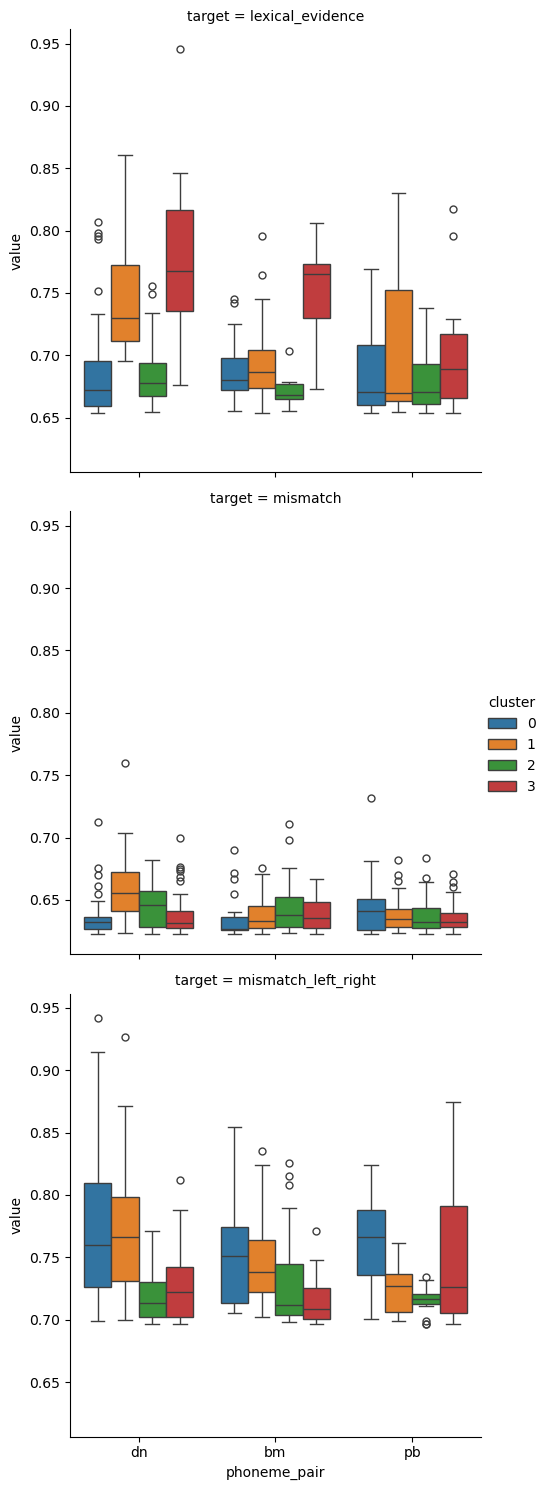

In [30]:
hue_order = sorted(all_cluster_results.cluster.value_counts().index)
g = sns.catplot(data=all_cluster_results, x="phoneme_pair", hue="cluster", hue_order=hue_order, y="value", row="target", kind="box")
# g.ax.set_ylim(0.48, 1)
# g.ax.axhline(0.5, linestyle="--", color="black")
# g.ax.set_ylabel("ROC/AUC")

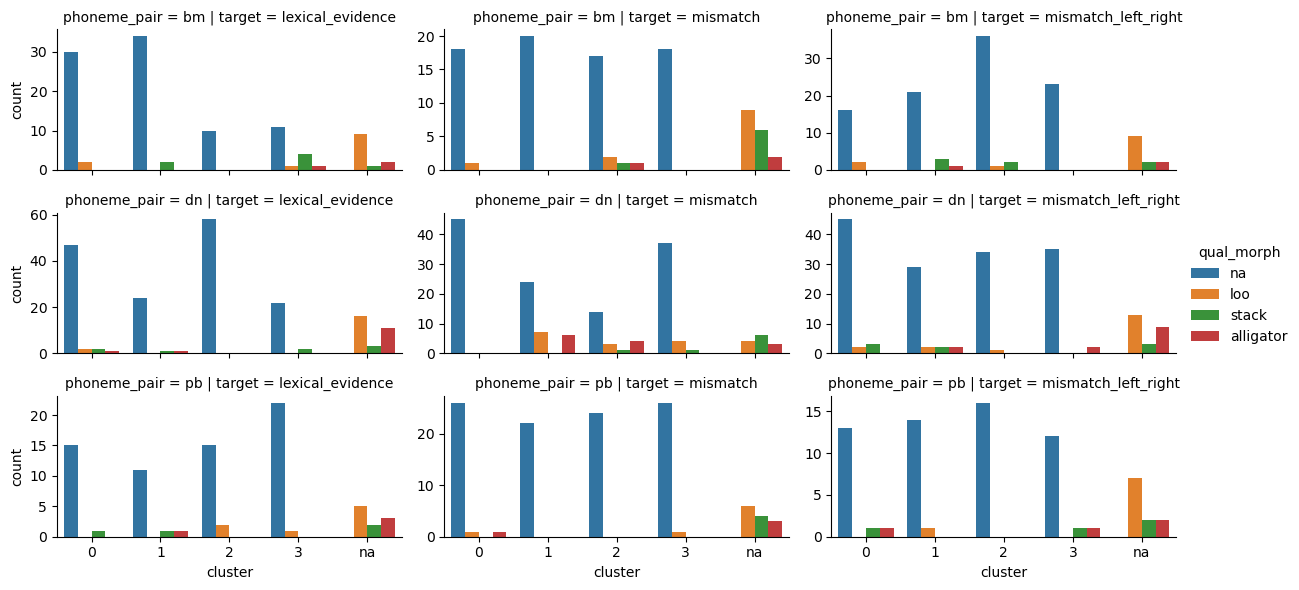

In [31]:
sns.catplot(data=all_cluster_results.fillna({"cluster": "na"}).groupby(["target", "phoneme_pair", "cluster"]).qual_morph.value_counts().reset_index(),
            x="cluster", hue="qual_morph", y="count", row="phoneme_pair", col="target", kind="bar", height=2, aspect=2,
            sharey=False)

/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_inde

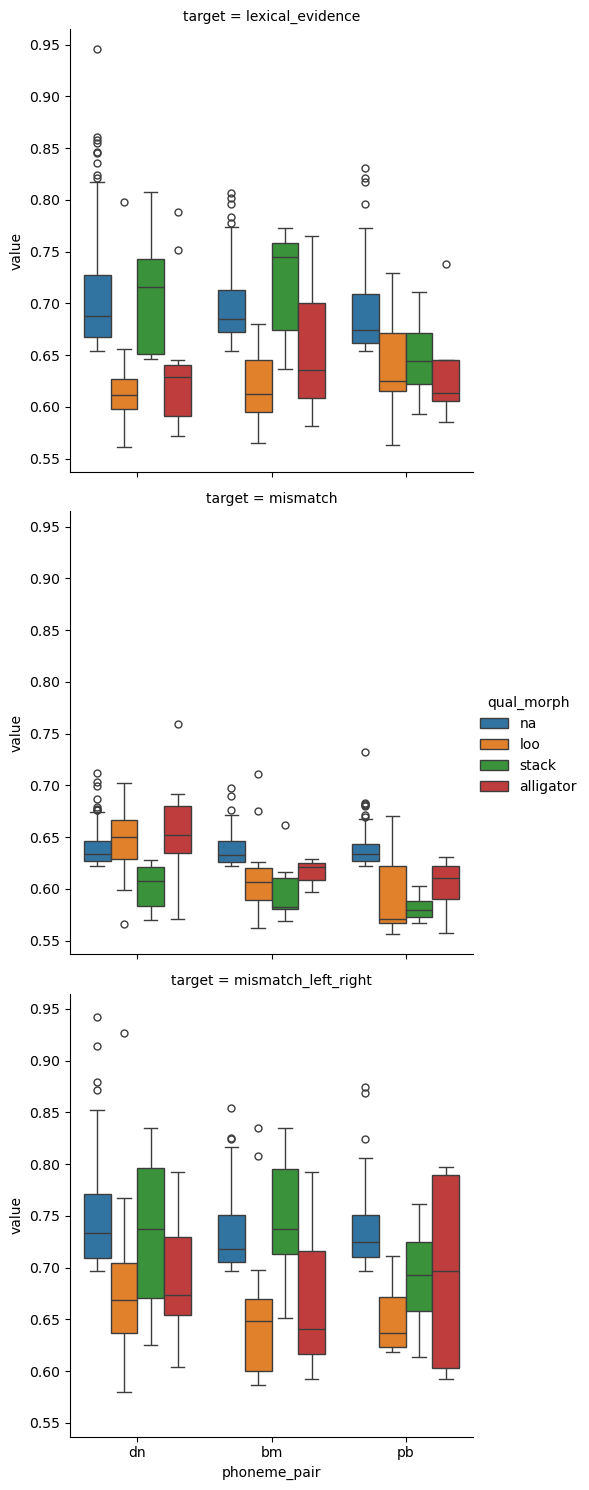

In [32]:
g = sns.catplot(data=all_cluster_results, x="phoneme_pair", hue="qual_morph", y="value", row="target", kind="box")
# g.ax.set_ylim(0.48, 1)
# g.ax.axhline(0.5, linestyle="--", color="black")
# g.ax.set_ylabel("ROC/AUC")

In [33]:
all_cluster_results.fillna({"cluster": "na"}).groupby(["target", "phoneme_pair", "qual_morph", "cluster"]).size().unstack("cluster").fillna(0).astype(int)

cluster                                       0   1   2   3  na
target              phoneme_pair qual_morph                    
lexical_evidence    bm           alligator    0   0   0   1   2
                                 loo          2   0   0   1   9
                                 na          30  34  10  11   0
                                 stack        0   2   0   4   1
                    dn           alligator    1   1   0   0  11
                                 loo          2   0   0   0  16
                                 na          47  24  58  22   0
                                 stack        2   1   0   2   3
                    pb           alligator    0   1   0   0   3
                                 loo          0   0   2   1   5
                                 na          15  11  15  22   0
                                 stack        1   1   0   0   2
mismatch            bm           alligator    0   0   1   0   2
                                 loo          1   0   2   0   9
                                 na          18  20  17  18   0
                                 stack        0   0   1   0   6
                    dn           alligator    0   6   4   0   3
                                 loo          0   7   3   4   4
                                 na          45  24  14  37   0
                                 stack        0   0   1   1   6
                    pb           alligator    1   0   0   0   3
                                 loo          1   0   0   1   6
                                 na          26  22  24  26   0
                                 stack        0   0   0   0   4
mismatch_left_right bm           alligator    0   1   0   0   2
                                 loo          2   0   1   0   9
                                 na          16  21  36  23   0
                                 stack        0   3   2   0   2
                    dn           alligator    0   2   0   2   9
                                 loo          2   2   1   0  13
                                 na          45  29  34  35   0
                                 stack        3   2   0   0   3
                    pb           alligator    1   0   0   1   2
                                 loo          0   1   0   0   7
                                 na          13  14  16  12   0
                                 stack        1   0   0   1   2

In [34]:
all_cluster_results.to_csv("single_electrode_clustering.csv")

In [35]:
results_bm

NameError: name 'results_bm' is not defined

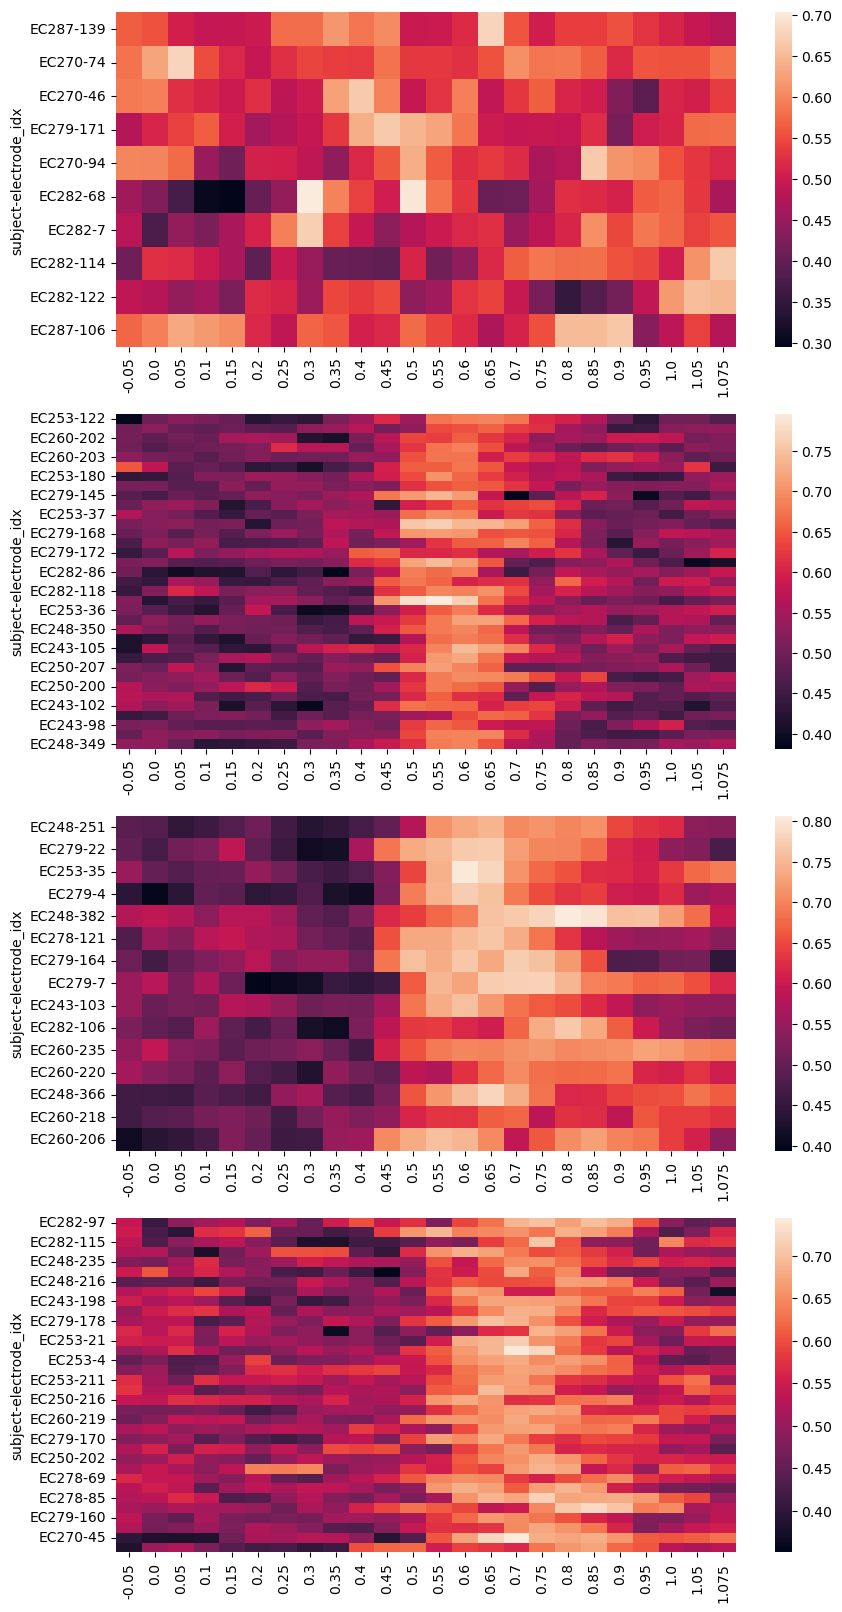

In [ ]:
cluster_heatmap_data = pd.merge(
        scores_avg.query("phoneme_pair == 'bm'").set_index(["subject", "electrode_idx", "t_center"]).roc_auc.unstack("t_center"),
        results_bm.set_index(["subject", "electrode_idx"]).cluster, left_index=True, right_index=True, how="inner") \
    .sort_values("cluster")
cluster_heatmap_data = [cluster_heatmap_data.query(f"cluster == '{cluster_idx}'").drop(columns=["cluster"])
                        for cluster_idx in sorted(cluster_heatmap_data.cluster.unique())]

f, axs = plt.subplots(len(cluster_heatmap_data), 1, figsize=(10, 5 * len(cluster_heatmap_data)))
for ax, cluster_data in zip(axs, cluster_heatmap_data):
    sns.heatmap(cluster_data, ax=ax)

In [ ]:
scores_avg.query("phoneme_pair == 'bm'").set_index(["subject", "electrode_idx", "t_center"]).roc_auc.unstack("t_center")

t_center                 -0.050     0.000     0.050     0.100     0.150  \
subject electrode_idx                                                     
EC243   54             0.517650  0.526331  0.445602  0.408709  0.447627   
        55             0.549913  0.484954  0.497396  0.462674  0.458623   
        59             0.443142  0.446181  0.449653  0.452257  0.484375   
        63             0.582321  0.589410  0.559606  0.540799  0.504340   
        64             0.545284  0.539497  0.522135  0.536892  0.474826   
...                         ...       ...       ...       ...       ...   
EC287   188            0.549154  0.542969  0.539062  0.543294  0.570638   
        190            0.406250  0.393555  0.430664  0.571289  0.571289   
        198            0.483073  0.513672  0.545898  0.489583  0.575195   
        199            0.482422  0.507812  0.542318  0.504883  0.493164   
        201            0.525065  0.473958  0.433268  0.409505  0.401042   

t_center                  0.200     0.250     0.300     0.350     0.400  ...  \
subject electrode_idx                                                    ...   
EC243   54             0.481337  0.510995  0.513889  0.482784  0.494358  ...   
        55             0.498553  0.487992  0.479022  0.507378  0.485822  ...   
        59             0.504485  0.491753  0.504340  0.497106  0.496962  ...   
        63             0.537326  0.535012  0.532118  0.480613  0.457031  ...   
        64             0.474392  0.458189  0.485532  0.489728  0.483073  ...   
...                         ...       ...       ...       ...       ...  ...   
EC287   188            0.547526  0.492513  0.489909  0.446289  0.472005  ...   
        190            0.614258  0.605469  0.538086  0.555664  0.507812  ...   
        198            0.515625  0.507487  0.431315  0.480794  0.424805  ...   
        199            0.445638  0.478841  0.419596  0.411784  0.492839  ...   
        201            0.403971  0.413737  0.529622  0.495443  0.484701  ...   

t_center                  0.650     0.700     0.750     0.800     0.850  \
subject electrode_idx                                                     
EC243   54             0.603877  0.608218  0.556568  0.538773  0.529948   
        55             0.557870  0.580150  0.527344  0.527922  0.547598   
        59             0.473669  0.557870  0.549624  0.529225  0.510272   
        63             0.540943  0.575376  0.562211  0.436921  0.457321   
        64             0.504630  0.546875  0.539931  0.516493  0.528646   
...                         ...       ...       ...       ...       ...   
EC287   188            0.477214  0.522786  0.532552  0.493490  0.394857   
        190            0.527995  0.478516  0.466146  0.420247  0.450521   
        198            0.504557  0.543945  0.505208  0.533529  0.488281   
        199            0.435221  0.457357  0.488281  0.532227  0.555339   
        201            0.543294  0.568359  0.488932  0.422201  0.498047   

t_center                  0.900     0.950     1.000     1.050     1.075  
subject electrode_idx                                                    
EC243   54             0.530671  0.554398  0.529369  0.442274  0.431134  
        55             0.553675  0.609375  0.558449  0.537616  0.454861  
        59             0.535590  0.555266  0.479167  0.440683  0.507378  
        63             0.477865  0.468461  0.489873  0.501302  0.503762  
        64             0.598235  0.555266  0.447627  0.493490  0.506944  
...                         ...       ...       ...       ...       ...  
EC287   188            0.480794  0.429688  0.435221  0.431966  0.453125  
        190            0.465495  0.536784  0.579102  0.482096  0.425781  
        198            0.525065  0.447591  0.468424  0.544596  0.547526  
        199            0.503906  0.480794  0.580729  0.614909  0.593750  
        201            0.525065  0.552083  0.516927  0.572591  0.560872  

[1074 rows x 24 columns]